<a href="https://colab.research.google.com/github/BenavidezYzquierdoSanchez/CDP26/blob/main/Sistema_Deteccion_Fraude_Tarjetas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Detección de Fraude en Tarjetas de Crédito

**Curso:** Programación para Ciencia de Datos
**Docente:** Mayeta Revilla Leondry
**Estudiantes:** Benavidez Yzquierdo Sanchez · Marvin Joel Aguilar Tunco · Jenson Daniel Chambi Aguilar
**Dataset:** `fraudes_tarjeta_procesado.csv` (339,607 transacciones, oeste de EE.UU., 2019-2020)
**Objetivo:** Construir, evaluar y explicar un modelo de Machine Learning capaz de estimar la probabilidad de que una transacción con tarjeta de crédito sea fraudulenta, y dejarlo listo para producción (exportado a JSON para una demo web en JavaScript).

---

## ¿Qué encontrarás en este notebook?

1. **Carga de datos** — lectura del CSV y primer vistazo.
2. **Análisis Exploratorio de Datos (EDA)** — patrones de fraude por monto, hora, categoría de comercio, mes y ubicación.
3. **Ingeniería de características** — variables derivadas (`es_noche`, `distancia_km`) y codificación de categóricas.
4. **Preparación de datos** — partición train/test y manejo del desbalance de clases.
5. **Entrenamiento del modelo** — por qué no Regresión Lineal/Logística, y entrenamiento de Random Forest.
6. **Evaluación** — matriz de confusión, curvas ROC y Precision-Recall, selección del umbral óptimo.
7. **Interpretabilidad** — importancia de variables y SHAP.
8. **Simulador interactivo** — calculadora de probabilidad de fraude dentro del propio notebook.
9. **Exportación del modelo** — a `joblib` (Python) y a `JSON` (para la versión HTML/JavaScript).
10. **Conclusiones y recomendaciones de negocio.**

> **Nota para Google Colab:** todas las celdas están pensadas para ejecutarse de arriba hacia abajo (`Entorno de ejecución -> Ejecutar todas`). La primera celda instala las librerías que Colab no trae preinstaladas.

## Contexto del proyecto

### 1. Objetivo del proyecto
**¿Qué problema de dominio resuelve este análisis?**

El fraude con tarjetas de crédito genera pérdidas económicas para bancos, comercios y titulares, y erosiona la confianza en los medios de pago digitales. El reto central no es únicamente "detectar el fraude", sino hacerlo bajo dos restricciones que compiten entre sí:

1. **El fraude es un evento raro** (0.52% de las transacciones en este dataset). Un sistema ingenuo puede lograr una accuracy altísima (99.48%) sin detectar ni un solo caso real, simplemente prediciendo "legítima" siempre.
2. **Cada tipo de error tiene un costo distinto.** Bloquear una transacción legítima (falso positivo) genera fricción y molestia al cliente; dejar pasar un fraude real (falso negativo) genera una pérdida económica directa. Ambos costos deben equilibrarse, no minimizarse por separado.

El **objetivo** de este proyecto es construir un sistema que estime, en tiempo real, la probabilidad de que una transacción con tarjeta de crédito sea fraudulenta a partir de sus características observables (monto, hora, categoría de comercio, entre otras), y que permita calibrar el punto de decisión (aprobar / revisar / bloquear) según el apetito de riesgo del negocio, en lugar de depender de reglas fijas o del juicio manual de un analista para cada caso.

### 2. Datos y fuente

El análisis usa `fraudes_tarjeta_procesado.csv`, un dataset público de **339,607 transacciones** con tarjeta de crédito en el oeste de Estados Unidos, entre **2019 y 2020**, con una tasa real de fraude de **0.52%** (1,782 casos). El archivo llega ya "procesado": conserva las columnas originales (monto, comercio, categoría, ubicación del cliente y del comercio, ocupación, fecha de nacimiento, fecha/hora de la transacción, y la etiqueta `is_fraud`) y agrega variables ya derivadas (`mes`, `hora`, `edad`, `rango_monto`). En la sección 4 de este notebook se documenta explícitamente qué columnas se usan como predictoras, cuáles se excluyen (y por qué) y qué variables adicionales se derivan (`es_noche`, `distancia_km`).

### 3. Diseño del código

El código sigue un diseño modular tipo *pipeline*, donde cada sección resuelve una única responsabilidad y entrega su salida a la siguiente: carga → análisis exploratorio → ingeniería de características → partición de datos → manejo del desbalance → entrenamiento del modelo → evaluación → optimización de umbral → interpretabilidad → exportación. Tres decisiones de diseño sostienen esta arquitectura:

- **Reproducibilidad total**, mediante una semilla fija (`RANDOM_STATE = 42`) en cada paso aleatorio (partición de datos, entrenamiento del modelo), para que cualquier persona que ejecute este notebook obtenga exactamente los mismos resultados.
- **Selección de modelo justificada, no comparada a ciegas**: en vez de entrenar varios algoritmos y quedarse con el que gane en una tabla, se analiza primero (sección 7.1) por qué un modelo de regresión no encaja con la naturaleza no lineal del problema, y se entrena directamente Random Forest con esa justificación de por medio.
- **Un contrato de variables fijo** (`orden_final_features`), que permite exportar el modelo entrenado en Python a una versión equivalente en JavaScript, verificada línea por línea para producir exactamente las mismas predicciones — el puente entre este notebook analítico y el dashboard interactivo entregado junto a él.

### 4. Relación con resultados de aprendizaje

Este proyecto integra competencias propias de un curso de Ciencia de Datos aplicada: análisis exploratorio y comunicación de hallazgos con datos reales, preprocesamiento y selección de variables justificada estadísticamente, entrenamiento y comparación de modelos supervisados, evaluación con métricas apropiadas para clases desbalanceadas (más allá de la accuracy), interpretabilidad de modelos de caja negra (importancia de variables y SHAP), y despliegue de un modelo entrenado a un entorno productivo (exportación a JSON para ejecución en el navegador).

**Decisión — ¿Qué decisión concreta orienta el resultado?**
El resultado orienta una decisión operativa de tres niveles sobre cada transacción individual: **aprobarla automáticamente, marcarla para revisión manual, o bloquearla de forma automática**, según si su probabilidad estimada de fraude supera los umbrales calibrados en la sección 8.4 (15% para revisión, 70% para bloqueo automático).

**Destinatario — ¿Para quién es relevante el resultado?**
- **Equipos de prevención de fraude / riesgo**, que revisarían manualmente las transacciones marcadas como sospechosas.
- **Equipos de ingeniería y producto**, responsables de integrar el modelo (o su versión exportada a JSON) en el flujo real de autorización de transacciones.
- **Gerencia de negocio**, que define cuánta fricción al cliente está dispuesta a aceptar a cambio de capturar más fraude — el *trade-off* que se cuantifica en la sección 8.
- **Indirectamente, los titulares de tarjeta**, como beneficiarios de un sistema que busca minimizar tanto el fraude no detectado como los bloqueos innecesarios de compras legítimas.

## 1. Instalación de librerías

Colab trae preinstaladas `pandas`, `numpy`, `matplotlib`, `seaborn` y `scikit-learn`, pero **no** trae `shap` (interpretabilidad) siempre en su última versión. La siguiente celda la instala. El flag `-q` (quiet) evita que se imprima todo el proceso de instalación.

In [1]:
# Instalamos la única librería adicional que necesitamos y que Colab no trae por defecto.
# shap -> interpretabilidad de modelos (explica por qué el modelo predice lo que predice)
!pip install -q shap

Con las librerías instaladas, importamos todo lo que usaremos en el resto del notebook. Fijamos también una semilla aleatoria (`RANDOM_STATE`) para que los resultados sean reproducibles: cualquier persona que ejecute este mismo notebook debería obtener exactamente los mismos números.

In [9]:
# --- Manejo de datos ---
import pandas as pd                     # manipulación de datos tabulares (DataFrames)
import numpy as np                      # operaciones numéricas y vectoriales
import json                             # para exportar el modelo final a formato JSON
import warnings                         # para silenciar advertencias no críticas de las librerías
warnings.filterwarnings('ignore')       # evita que warnings de sklearn saturen la salida

# --- Visualización ---
import matplotlib.pyplot as plt         # gráficos base
import seaborn as sns                   # gráficos estadísticos con mejor estética por defecto
%matplotlib inline

# --- Preprocesamiento y partición de datos ---
from sklearn.model_selection import train_test_split

# --- Modelo ---
from sklearn.ensemble import RandomForestClassifier

# --- Métricas de evaluación ---
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, precision_score, recall_score, f1_score
)

# --- Interpretabilidad ---
import shap

# --- Guardado del modelo entrenado ---
import joblib

# --- Reproducibilidad ---
RANDOM_STATE = 42                       # semilla fija: mismos resultados en cada ejecución

# --- Paleta de colores consistente para todo el notebook ---
COLOR_FRAUDE = '#DC2626'                # rojo -> siempre representa "fraude" en los gráficos
COLOR_LEGIT  = '#334155'                # gris azulado -> siempre representa "transacción legítima"
sns.set_style('whitegrid')              # estilo limpio con líneas de referencia suaves
plt.rcParams['figure.dpi'] = 100         # nitidez de los gráficos

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


### 1.1 Librerías usadas y por qué

| Librería | Rol en este proyecto |
|---|---|
| **pandas** | Cargar el CSV y manipular los datos en forma de tabla (`DataFrame`): agrupar, filtrar, calcular tasas por categoría/hora/mes, etc. |
| **numpy** | Operaciones numéricas vectorizadas (por ejemplo, la fórmula de Haversine para calcular distancias) mucho más rápidas que un bucle `for` en Python puro. |
| **matplotlib** | Motor base de todos los gráficos (histogramas, curvas ROC/PR, matrices de confusión). |
| **seaborn** | Capa sobre matplotlib con mejor estética por defecto; se usa para los boxplots y el mapa de calor de correlación. |
| **scikit-learn** | La librería central de Machine Learning: `train_test_split` (partición train/test), `RandomForestClassifier` (el modelo), y las métricas de evaluación (`roc_auc_score`, `precision_score`, etc.). |
| **shap** | Interpretabilidad: explica qué variables empujan cada predicción hacia "fraude" o "legítima", y en qué dirección. |
| **joblib** | Guardar el modelo Random Forest ya entrenado en un archivo (`.joblib`) para poder reutilizarlo sin reentrenar. |
| **json** | Exportar la estructura interna del bosque a un archivo `.json` liviano, que la versión HTML/JavaScript del sistema recorre para predecir en el navegador. |
| **ipywidgets** *(sección 10)* | Construir la calculadora interactiva con sliders dentro del propio notebook. |

**Nota:** en una versión anterior de este proyecto se evaluó también XGBoost como alternativa a Random Forest; se retiró de la versión final para mantener un único modelo de producción, por lo que la librería `xgboost` ya no es una dependencia de este notebook.

## 2. Carga de datos

La siguiente celda busca el archivo `fraudes_tarjeta_procesado.csv` en la sesión actual de Colab. Si no lo encuentra (por ejemplo, la primera vez que ejecutas el notebook), abre automáticamente el diálogo de carga de archivos para que lo selecciones desde tu computadora. Si ejecutas esto fuera de Colab (Jupyter local), simplemente coloca el CSV en la misma carpeta que el notebook.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

# Nombre esperado del archivo de datos
ruta_archivo = '/content/drive/MyDrive/PCDP26/fraudes_tarjeta_procesado.csv'

# Si el archivo no existe todavía en el entorno, intentamos subirlo (funciona en Google Colab)
if not os.path.exists(ruta_archivo):
    try:
        from google.colab import files                 # solo existe dentro de Google Colab
        print('Selecciona el archivo fraudes_tarjeta_procesado.csv en la ventana que se abrirá...')
        archivos_subidos = files.upload()               # abre el diálogo de carga
        ruta_archivo = list(archivos_subidos.keys())[0] # tomamos el nombre real del archivo subido
    except ImportError:
        # Si no estamos en Colab y el archivo no existe, avisamos con un mensaje claro
        raise FileNotFoundError(
            'No se encontró fraudes_tarjeta_procesado.csv. '
            'Si no usas Google Colab, copia el CSV a la misma carpeta que este notebook.'
        )

# Cargamos el CSV en un DataFrame de pandas
df = pd.read_csv(ruta_archivo)

# Mostramos un resumen rápido para confirmar que la carga fue exitosa
print(f'Datos cargados correctamente: {df.shape[0]:,} transacciones, {df.shape[1]} columnas.')
df.head()

Datos cargados correctamente: 339,607 transacciones, 19 columnas.


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,mes,hora,edad,rango_monto
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0,1,0,41,Medio
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0,1,0,57,Medio
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0,1,0,74,Medio
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0,1,0,52,Bajo
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0,1,0,52,Bajo


**Interpretación:** el dataset contiene **339,607 transacciones** con **19 columnas**. Cada fila es una transacción individual con tarjeta de crédito, e incluye datos del comercio (`merchant`, `category`), del cliente (`city`, `state`, `job`, `dob`), del monto (`amt`) y la variable objetivo `is_fraud` (1 = fraude, 0 = legítima). Las columnas `mes`, `hora`, `edad` y `rango_monto` ya vienen pre-calculadas en este CSV "procesado".

In [11]:
df[df['rango_monto'].isnull()]

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,mes,hora,edad,rango_monto
144783,2019-12-01 16:19:23,Satterfield-Lowe,travel,28948.9,Westerville,NE,41.4193,-99.3844,73,Product designer,1935-02-10,309c4bf7fc47b1ddee5ad883bcf634b6,42.317313,-99.139498,0,12,16,84,NaN


## 3. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, necesitamos entender los datos: su estructura, calidad y, sobre todo, **qué patrones separan a las transacciones fraudulentas de las legítimas**. Estos patrones son los que luego el modelo aprenderá a detectar.

### 3.1 Estructura general y tipos de datos

In [14]:
# info() muestra: nombre de columna, cantidad de valores no nulos y tipo de dato de cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

**Interpretación:** tenemos columnas numéricas (`amt`, `lat`, `long`, `city_pop`, `mes`, `hora`, `edad`), de texto/categóricas (`merchant`, `category`, `city`, `state`, `job`, `rango_monto`) y una columna de fecha (`trans_date_trans_time`) que pandas todavía lee como texto. Más adelante la convertiremos a un tipo de fecha real para poder extraer información temporal adicional si la necesitamos.

### 3.2 Valores nulos

In [15]:
# isnull().sum() cuenta cuántos valores faltantes (NaN) hay por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]  # nos quedamos solo con las columnas que sí tienen nulos
print('Columnas con valores nulos:')
print(nulos if len(nulos) > 0 else 'Ninguna columna tiene valores nulos.')

Columnas con valores nulos:
rango_monto    1
dtype: int64


**Interpretación:** el dataset está prácticamente limpio: solo `rango_monto` tiene **1 valor nulo** de 339,607 filas (0.0003%).

**¿Cómo se trata un valor nulo, en general?** Las estrategias más comunes, de menor a mayor "invasivas":

1. **Imputación** — reemplazar el nulo por la media, mediana o moda de la columna (o un valor estimado a partir de otras columnas).
2. **Eliminación de la fila** — descartar esa observación completa; razonable solo cuando son muy pocos casos y no introduce sesgo.
3. **Eliminación de la columna** — si la columna no aporta información necesaria (por ejemplo, es redundante con otra variable que sí se conserva).

**Tratamiento elegido aquí: opción 3.** `rango_monto` es una versión ya "bucketizada" de `amt` (lo justificamos en la sección 4) y **no forma parte del conjunto de variables del modelo**. Al excluir la columna completa, el nulo queda resuelto automáticamente — sin necesidad de imputar un valor inventado ni de sacrificar esa fila (que sí aporta una transacción válida en el resto de sus columnas). Lo verificamos a continuación.

In [35]:
# Verificación: una vez excluidas las columnas que no se usan como variables del modelo (sección 4),
# ¿queda algún nulo en los datos que sí entran a entrenar?
columnas_modelo_verificacion = ['amt', 'hora', 'mes', 'edad', 'city_pop', 'category', 'state',
                                 'lat', 'long', 'merch_lat', 'merch_long', 'is_fraud']
print('Nulos en las columnas que sí se usan para el modelo:', df[columnas_modelo_verificacion].isnull().sum().sum())

Nulos en las columnas que sí se usan para el modelo: 0


**Interpretación:** el resultado es **0 nulos** en las columnas que efectivamente alimentan al modelo. No se imputó ningún valor ni se eliminó ninguna fila del dataset — las 339,607 transacciones originales se conservan intactas.

### 3.3 Distribución de la variable objetivo (`is_fraud`)

Esta es la pregunta más importante del proyecto: **¿qué tan desbalanceadas están las clases?**

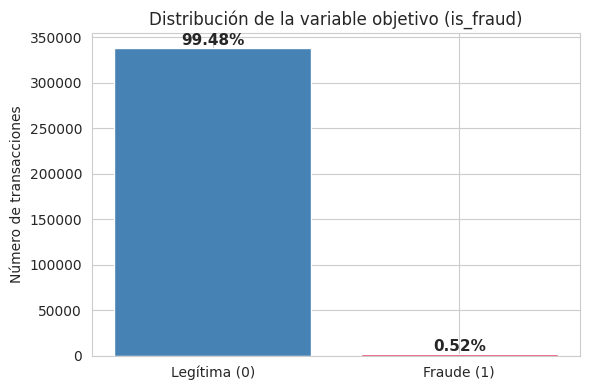

In [13]:
# Conteo absoluto y porcentual de cada clase
# Conteo absoluto y porcentual de cada clase
conteo_clases = df['is_fraud'].value_counts().sort_index()
porcentaje_clases = df['is_fraud'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))

barras = plt.bar(
    ['Legítima (0)', 'Fraude (1)'],
    conteo_clases,
    color=['steelblue', 'crimson']
)

for barra, pct in zip(barras, porcentaje_clases):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f'{pct:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("Número de transacciones")
plt.title("Distribución de la variable objetivo (is_fraud)")
plt.tight_layout()
plt.show()

**Interpretación:** el dataset está **extremadamente desbalanceado**: solo el **0.52%** de las transacciones (1,782 de 339,607) son fraude. Esto es realista — el fraude es, por suerte, un evento raro — pero tiene una consecuencia estadística importante: un modelo "tonto" que prediga *siempre* "legítima" acertaría el 99.48% de las veces (accuracy altísima) sin detectar ni un solo fraude. Por eso, en las secciones 6 y 8 vamos a **evitar la accuracy como métrica principal** y usar en su lugar precisión, recall, AUC-ROC y AUC-PR, además de técnicas específicas para el desbalance de clases.

### 3.4 Distribución del monto de la transacción (`amt`)

Estadísticas de "amt" por clase:
             count    mean     std   min     25%     50%     75%       max
is_fraud                                                                  
0         337825.0   68.22  156.25  1.00    9.57   46.25   82.76  28948.90
1           1782.0  518.07  389.63  1.78  214.68  356.44  884.72   1371.81


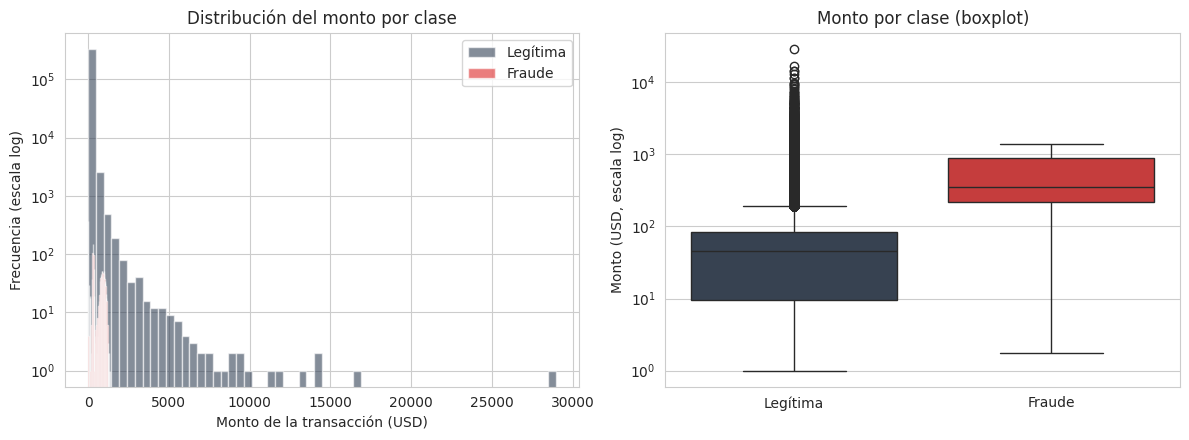

In [16]:
# Comparamos estadísticas descriptivas del monto separando fraude vs legítimas
print('Estadísticas de "amt" por clase:')
print(df.groupby('is_fraud')['amt'].describe().round(2))

# Histograma en escala logarítmica (porque el monto tiene una cola muy larga hacia montos altos)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: histogramas superpuestos (alpha=0.6 los hace semi-transparentes para poder ver ambos a la vez)
axes[0].hist(df[df['is_fraud']==0]['amt'], bins=60, alpha=0.6, label='Legítima', color=COLOR_LEGIT, log=True)
axes[0].hist(df[df['is_fraud']==1]['amt'], bins=60, alpha=0.6, label='Fraude', color=COLOR_FRAUDE, log=True)
axes[0].set_xlabel('Monto de la transacción (USD)')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].set_title('Distribución del monto por clase')
axes[0].legend()

# Panel derecho: boxplot para comparar medianas y dispersión de forma más directa
sns.boxplot(data=df, x='is_fraud', y='amt', ax=axes[1], palette=[COLOR_LEGIT, COLOR_FRAUDE])
axes[1].set_yscale('log')  # misma razón que el histograma: sin esto, los valores extremos aplastarían la escala
axes[1].set_xticklabels(['Legítima', 'Fraude'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Monto (USD, escala log)')
axes[1].set_title('Monto por clase (boxplot)')

plt.tight_layout()
plt.show()

**Interpretación:** las transacciones fraudulentas tienen un monto **promedio de \$518**, casi **8 veces mayor** que el promedio de las transacciones legítimas (\$68). El boxplot confirma que la mediana del fraude está muy por encima de la mediana legítima. Esto convierte a `amt` en una de las variables más informativas para detectar fraude: los defraudadores tienden a intentar extraer el mayor valor posible por transacción antes de que la tarjeta sea bloqueada.

### 3.5 Fraude según la hora del día

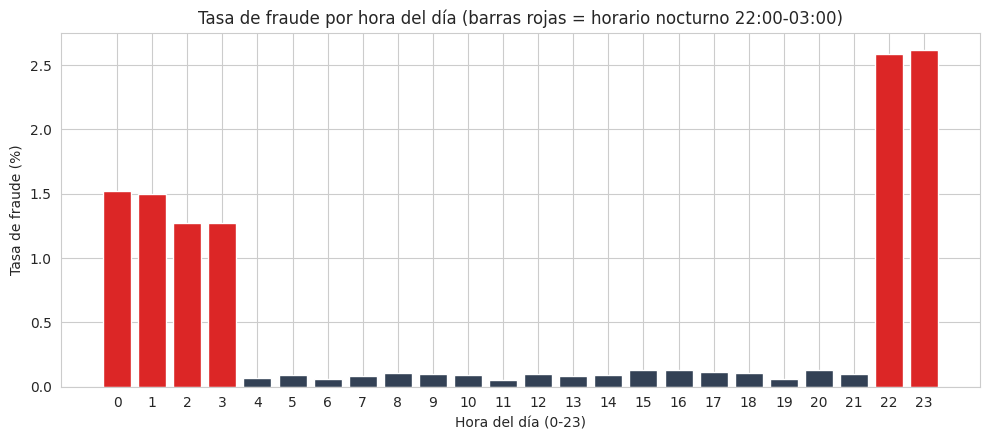

Tasa de fraude en horario nocturno (22h-03h): 1.924 %
Tasa de fraude en horario diurno (04h-21h):   0.097 %


In [17]:
# Calculamos la tasa de fraude (%) para cada hora del día (0 a 23)
tasa_por_hora = df.groupby('hora')['is_fraud'].mean() * 100

plt.figure(figsize=(10, 4.5))
colores_barras = [COLOR_FRAUDE if h in [22, 23, 0, 1, 2, 3] else COLOR_LEGIT for h in tasa_por_hora.index]
plt.bar(tasa_por_hora.index, tasa_por_hora.values, color=colores_barras)
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude por hora del día (barras rojas = horario nocturno 22:00-03:00)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print('Tasa de fraude en horario nocturno (22h-03h):', round(df[df['hora'].isin([22,23,0,1,2,3])]['is_fraud'].mean()*100, 3), '%')
print('Tasa de fraude en horario diurno (04h-21h):  ', round(df[~df['hora'].isin([22,23,0,1,2,3])]['is_fraud'].mean()*100, 3), '%')

**Interpretación:** hay un patrón horario clarísimo. Entre las **22:00 y las 03:00** la tasa de fraude sube a **1.3%-2.6%**, mientras que durante el resto del día se mantiene por debajo del **0.15%**. En otras palabras, una transacción nocturna tiene aproximadamente **15-20 veces más probabilidad** de ser fraude que una diurna. Este hallazgo justifica crear una variable binaria `es_noche` en la sección 4: en vez de dejar que el modelo intente "descubrir" este patrón hora por hora, se lo entregamos ya resumido.

### 3.6 Fraude según la categoría del comercio

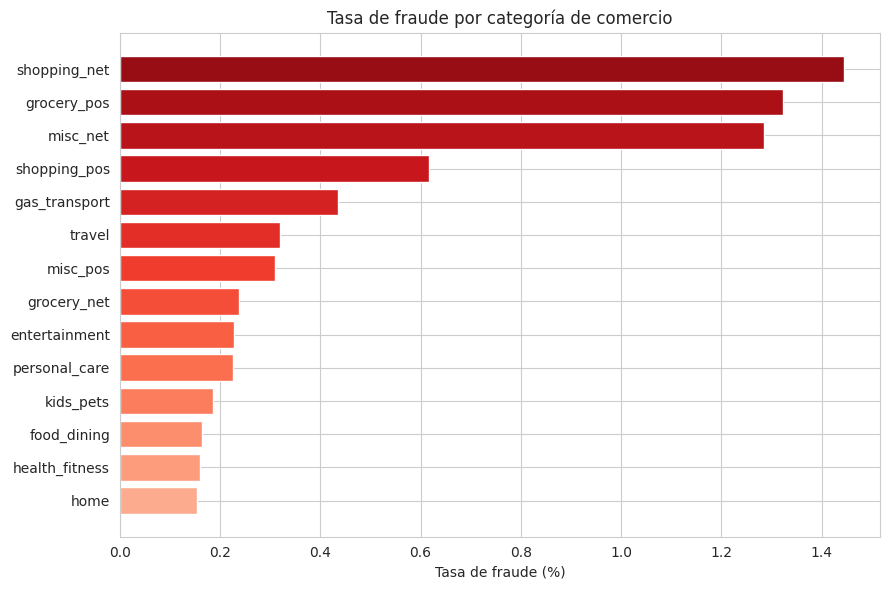

category
shopping_net      1.444
grocery_pos       1.323
misc_net          1.284
shopping_pos      0.617
gas_transport     0.436
travel            0.320
misc_pos          0.310
grocery_net       0.238
entertainment     0.227
personal_care     0.225
kids_pets         0.185
food_dining       0.165
health_fitness    0.159
home              0.154
Name: is_fraud, dtype: float64


In [18]:
# Tasa de fraude por categoría de comercio, ordenada de mayor a menor
tasa_por_categoria = (df.groupby('category')['is_fraud'].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
# Usamos un degradado de rojo: las categorías más riesgosas se ven en rojo más intenso
colores = plt.cm.Reds(np.linspace(0.9, 0.3, len(tasa_por_categoria)))
plt.barh(tasa_por_categoria.index, tasa_por_categoria.values, color=colores)
plt.xlabel('Tasa de fraude (%)')
plt.title('Tasa de fraude por categoría de comercio')
plt.gca().invert_yaxis()  # la categoría con más fraude queda arriba
plt.tight_layout()
plt.show()

print(tasa_por_categoria.round(3))

**Interpretación:** las categorías **`shopping_net`** (1.44%), **`grocery_pos`** (1.32%) y **`misc_net`** (1.28%) concentran el mayor riesgo — hasta **9 veces más** que categorías seguras como `home` (0.15%) o `health_fitness` (0.16%). Es interesante notar que dos de las tres categorías más riesgosas son de comercio **online** (`_net`), lo cual es consistente con la naturaleza del fraude en tarjetas: las compras "card-not-present" (sin la tarjeta física presente) son más fáciles de falsificar.

### 3.7 Fraude según el mes del año

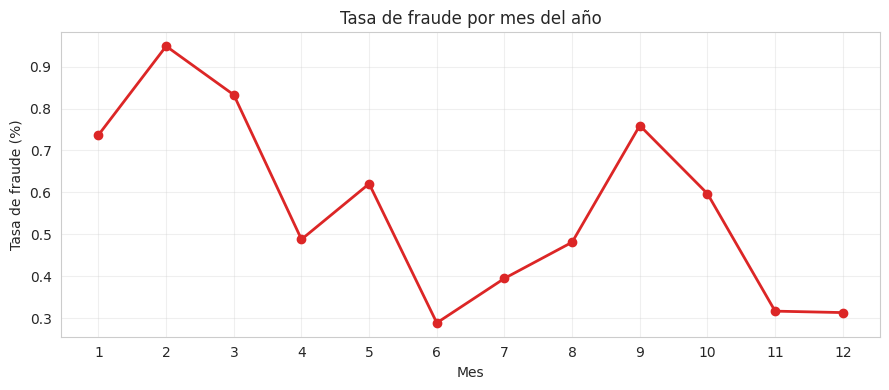

In [19]:
# Agrupamos por mes (1=enero ... 12=diciembre) y calculamos qué porcentaje de las
# transacciones de cada mes resultaron ser fraude
tasa_por_mes = df.groupby('mes')['is_fraud'].mean() * 100

plt.figure(figsize=(9, 4))                                  # lienzo ancho y bajo: ideal para una serie de 12 puntos en el tiempo
plt.plot(tasa_por_mes.index, tasa_por_mes.values,            # eje X = mes (1-12), eje Y = tasa de fraude (%)
         marker='o', color=COLOR_FRAUDE, linewidth=2)        # marcador circular en cada mes para ver el valor exacto de cada punto
plt.xlabel('Mes')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude por mes del año')
plt.xticks(range(1, 13))                                     # forzamos a mostrar los 12 meses en el eje, no solo algunos
plt.grid(alpha=0.3)                                          # cuadrícula tenue de referencia, sin competir visualmente con la línea
plt.tight_layout()                                           # ajusta márgenes para que ninguna etiqueta quede cortada
plt.show()

**Interpretación:** existe variación estacional (entre 0.29% en junio y 0.95% en febrero), con un repunte notable en los primeros meses del año y en septiembre. El efecto es más moderado que el de la hora o la categoría, así que `mes` será una variable secundaria en el modelo: aporta información, pero no es tan decisiva como `amt`, `es_noche` o `category`.

### 3.8 Matriz de correlación entre variables numéricas

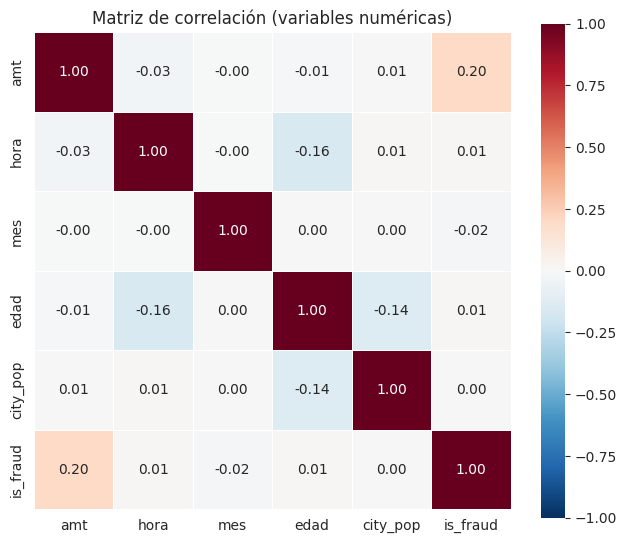

In [20]:
# Seleccionamos solo las columnas numéricas relevantes para calcular correlaciones
columnas_numericas = ['amt', 'hora', 'mes', 'edad', 'city_pop', 'is_fraud']
matriz_corr = df[columnas_numericas].corr()  # coeficiente de correlación de Pearson entre cada par de variables (-1 a 1)

plt.figure(figsize=(6.5, 5.5))
# cmap='RdBu_r' + center=0: colores divergentes (azul=negativo, rojo=positivo) centrados exactamente en 0,
# para que sea visualmente claro qué correlaciones son positivas y cuáles negativas
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

**Interpretación:** ninguna variable numérica individual tiene una correlación lineal fuerte con `is_fraud` (todas por debajo de 0.2 en valor absoluto) — lo cual es normal y esperado en fraude: la relación no es lineal, sino de **combinaciones e interacciones** (por ejemplo, "monto alto Y de noche Y en `shopping_net`"). Esto es evidencia temprana de por qué un modelo capaz de capturar interacciones no lineales, como Random Forest, es más adecuado aquí que un modelo de regresión lineal/logística simple (se retoma este punto con más detalle en la sección 7.1).

### 3.9 Distancia entre el cliente y el comercio

Un supuesto común en tutoriales de detección de fraude es que las transacciones fraudulentas ocurren más lejos del domicilio del cliente. Vamos a comprobarlo con los datos reales en vez de asumirlo.

Distancia cliente-comercio por clase:
           mean    std    50%
is_fraud                     
0         75.58  29.06  77.61
1         75.57  28.48  77.36


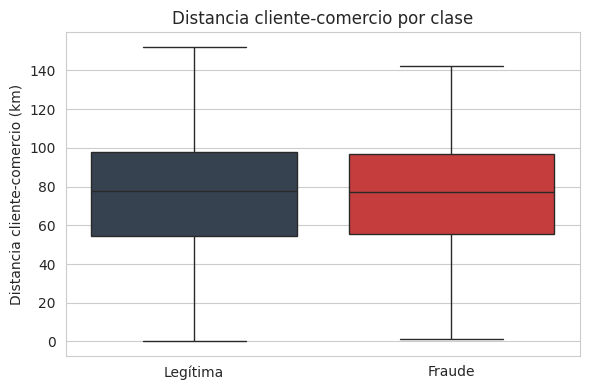

In [21]:
# Calculamos la distancia en kilómetros entre la ubicación del cliente (lat, long)
# y la ubicación del comercio (merch_lat, merch_long) usando la fórmula de Haversine,
# que calcula distancias sobre la superficie de una esfera (la Tierra) a partir de coordenadas.
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en kilómetros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)          # convertimos grados a radianes
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))                      # distancia en km

df['distancia_km'] = calcular_distancia_haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

print('Distancia cliente-comercio por clase:')
print(df.groupby('is_fraud')['distancia_km'].describe()[['mean', 'std', '50%']].round(2))

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='is_fraud', y='distancia_km', palette=[COLOR_LEGIT, COLOR_FRAUDE])
plt.xticks([0, 1], ['Legítima', 'Fraude'])
plt.xlabel('')
plt.ylabel('Distancia cliente-comercio (km)')
plt.title('Distancia cliente-comercio por clase')
plt.tight_layout()
plt.show()

**Interpretación (hallazgo relevante):** contrario a la suposición inicial, **la distancia NO diferencia el fraude en este dataset**: el promedio es prácticamente idéntico (75.58 km en legítimas vs 75.57 km en fraude). Mantenemos la variable en el modelo por completitud y para no descartarla sin evidencia, pero **no esperamos que aporte mucho poder predictivo** — algo que confirmaremos objetivamente en la sección 9 (importancia de variables). Es un buen ejemplo de por qué siempre hay que **verificar los supuestos con los datos**, en vez de asumir que un patrón "conocido" se repite igual en cada dataset.

## 4. Ingeniería de características (Feature Engineering)

Con base en lo descubierto en el EDA, preparamos el conjunto final de variables (*features*) que alimentará a los modelos.

**Variables que creamos:**
- `es_noche`: 1 si la transacción ocurrió entre las 22:00 y las 03:00, 0 en caso contrario (justificado en 3.5).
- `distancia_km`: ya calculada en 3.9.

**Variables que excluimos del modelo, y por qué:**
- `trans_num`, `merchant`, `job`, `city`: identificadores de muy alta cardinalidad (más de 150 valores distintos cada uno). Convertirlos en variables dummy generaría cientos de columnas con muy pocos datos cada una, lo que aumenta el riesgo de sobreajuste sin garantía de mejor desempeño.
- `dob`, `trans_date_trans_time`: ya están resumidas en `edad`, `hora` y `mes`, así que usar las columnas crudas sería redundante.
- `lat`, `long`, `merch_lat`, `merch_long`: ya están resumidas en `distancia_km`.
- `rango_monto`: es una versión "bucketizada" (Bajo/Medio/Alto) de `amt`. Usar ambas al mismo tiempo introduciría **redundancia y colinealidad** (la misma información contada dos veces), así que nos quedamos con `amt`, que conserva más detalle numérico.

**Variables categóricas que sí usamos (codificadas con one-hot encoding):** `category` (14 categorías) y `state` (13 estados).

In [22]:
# Convertimos la columna de fecha/hora a un tipo datetime real de pandas
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Creamos la variable binaria "es_noche": 1 si la hora está entre 22:00 y 03:00, 0 en caso contrario
df['es_noche'] = df['hora'].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Lista de variables numéricas que entrarán directamente al modelo
variables_numericas = ['amt', 'hora', 'es_noche', 'mes', 'edad', 'city_pop', 'distancia_km']

# Armamos un DataFrame reducido solo con las columnas que vamos a usar
df_modelo = df[variables_numericas + ['category', 'state', 'is_fraud']].copy()

# One-hot encoding: convierte cada categoría de "category" y "state" en su propia columna binaria (0/1)
# prefix=['cat','st'] nombra las nuevas columnas como cat_xxx y st_xxx para identificarlas fácilmente
df_modelo = pd.get_dummies(df_modelo, columns=['category', 'state'], prefix=['cat', 'st'], drop_first=False)

# Ordenamos las columnas de forma fija y predecible:
# primero las numéricas (en un orden fijo), luego las dummy de categoría, luego las de estado (ambas alfabéticas).
# Este orden ES IMPORTANTE: la versión JavaScript del modelo (sección 11) debe construir
# el vector de entrada exactamente en este mismo orden para que las predicciones coincidan.
columnas_categoria = sorted([c for c in df_modelo.columns if c.startswith('cat_')])
columnas_estado    = sorted([c for c in df_modelo.columns if c.startswith('st_')])
orden_final_features = variables_numericas + columnas_categoria + columnas_estado

X = df_modelo[orden_final_features].astype(float)  # todas las variables predictoras
y = df_modelo['is_fraud'].astype(int)              # variable objetivo

print(f'Matriz de variables predictoras (X): {X.shape[0]:,} filas x {X.shape[1]} columnas')
print(f'Variables numéricas ({len(variables_numericas)}):', variables_numericas)
print(f'Variables de categoría ({len(columnas_categoria)}):', columnas_categoria)
print(f'Variables de estado ({len(columnas_estado)}):', columnas_estado)

Matriz de variables predictoras (X): 339,607 filas x 34 columnas
Variables numéricas (7): ['amt', 'hora', 'es_noche', 'mes', 'edad', 'city_pop', 'distancia_km']
Variables de categoría (14): ['cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']
Variables de estado (13): ['st_AK', 'st_AZ', 'st_CA', 'st_CO', 'st_HI', 'st_ID', 'st_MO', 'st_NE', 'st_NM', 'st_OR', 'st_UT', 'st_WA', 'st_WY']


**Interpretación:** partimos de 19 columnas originales y llegamos a **34 variables predictoras** finales (7 numéricas + 14 de categoría + 13 de estado), todas en formato numérico y en un **orden fijo** (`orden_final_features`). Fijar el orden no es un detalle menor: es lo que nos permitirá, en la sección 11, exportar el modelo a JavaScript y garantizar que la demo web construya el vector de entrada exactamente igual que como se entrenó el modelo en Python.

## 5. Partición de datos

Dividimos los datos en un conjunto de **entrenamiento** (para que el modelo aprenda) y uno de **prueba** (para evaluar qué tan bien generaliza a datos que nunca vio). Usamos `stratify=y` para que la proporción de fraude (0.52%) se mantenga igual en ambos conjuntos — de lo contrario, con una clase tan minoritaria, podríamos terminar con muy pocos (o ningún) caso de fraude en el conjunto de prueba solo por azar.

Random Forest **no necesita** que las variables estén en la misma escala (a diferencia de modelos como la Regresión Logística): construye sus divisiones comparando una variable a la vez contra un umbral, no mediante distancias entre puntos, así que un escalador (`StandardScaler`) no aporta nada aquí y lo omitimos.

In [23]:
# train_test_split separa aleatoriamente los datos en entrenamiento (80%) y prueba (20%)
# stratify=y asegura que ambos conjuntos mantengan la misma proporción de fraude que el total
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} filas ({y_train.sum():,} fraudes, {y_train.mean()*100:.3f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} filas ({y_test.sum():,} fraudes, {y_test.mean()*100:.3f}%)')

Conjunto de entrenamiento: 271,685 filas (1,426 fraudes, 0.525%)
Conjunto de prueba:        67,922 filas (356 fraudes, 0.524%)


**Interpretación:** el conjunto de entrenamiento queda con **271,685 transacciones (1,426 fraudes)** y el de prueba con **67,922 transacciones (356 fraudes)**, ambos manteniendo la proporción original de 0.52% de fraude gracias a la estratificación.

## 6. Manejo del desbalance de clases

Con solo 0.52% de casos positivos, un modelo entrenado "normalmente" tiende a ignorar la clase minoritaria porque, en términos puramente matemáticos, casi siempre le conviene más predecir "legítima" y equivocarse pocas veces. La estrategia para compensarlo es asignar **más peso a los errores sobre la clase fraude** durante el entrenamiento, usando el parámetro `class_weight='balanced'` de scikit-learn, que automáticamente pondera la clase minoritaria (fraude) en proporción inversa a su frecuencia.

Esta técnica es preferible a duplicar filas de fraude artificialmente (*oversampling* ingenuo) porque no infla el tamaño del dataset ni genera copias idénticas que podrían causar sobreajuste.

## 7. Entrenamiento del modelo

### 7.1 ¿Por qué no Regresión Lineal o Regresión Logística?

Antes de entrenar, vale la pena justificar por qué este proyecto **no** usa un modelo de regresión como punto de partida — una pregunta razonable, ya que la Regresión Logística es un estándar de facto en detección de fraude.

**Regresión Lineal: descartada por diseño.** `is_fraud` es una variable **binaria** (0 o 1), no continua. Un modelo de regresión lineal está diseñado para predecir cantidades continuas (un precio, una temperatura) y, aplicado aquí, podría devolver valores fuera del rango \[0,1\] (por ejemplo -0.3 o 1.8), que no tienen ninguna interpretación como probabilidad. No es solo que rinda peor: es la herramienta equivocada para este tipo de variable objetivo.

**Regresión Logística: sí aplica a clasificación, pero con una limitación clave.** A diferencia de la lineal, sí está diseñada para variables binarias y sí devuelve probabilidades válidas entre 0 y 1. Pero asume una relación **log-lineal y aditiva**: el efecto de cada variable sobre la probabilidad de fraude se calcula de forma independiente y se suma al de las demás. Ya vimos evidencia directa en el EDA de que esta asunción no encaja bien con nuestros datos:

- En la sección 3.8, **ninguna variable numérica individual correlaciona fuertemente con el fraude** (todas por debajo de 0.2).
- El patrón real que sí separa fraude de legítimas es una **combinación de condiciones simultáneas** — por ejemplo, "monto alto **Y** horario nocturno **Y** categoría `shopping_net`" — no el efecto aislado de una sola variable.

Modelar estas interacciones con Regresión Logística exigiría crear manualmente términos de interacción (`monto × es_noche`, `monto × categoría`, etc.) para cada combinación relevante — un proceso propenso a errores, que no escala bien a medida que se agregan variables, y que depende de que el analista adivine correctamente qué interacciones importan.

**Por qué Random Forest resuelve esto de forma nativa.** Al ser un ensamble de árboles de decisión, cada división del árbol puede depender de los resultados de divisiones anteriores sobre *otras* variables — el modelo descubre las interacciones automáticamente a partir de los datos, sin que se le indique explícitamente cuáles buscar. Por eso este proyecto entrena directamente un Random Forest como modelo principal, en lugar de partir de un modelo de regresión y compararlo.

### 7.2 Random Forest

Random Forest entrena **muchos árboles de decisión** sobre distintas muestras aleatorias de los datos y de las variables, y promedia sus resultados. Esto le permite capturar relaciones no lineales e interacciones entre variables (por ejemplo, "monto alto **Y** de noche **Y** en `shopping_net`") sin necesitar que se las indiquemos manualmente.

In [24]:
modelo_rf = RandomForestClassifier(
    n_estimators=150,          # número de árboles en el bosque: más árboles = predicciones más estables
    max_depth=10,               # profundidad máxima de cada árbol: limita el sobreajuste
    min_samples_leaf=3,          # cada hoja del árbol debe tener al menos 3 muestras (evita hojas "de un solo caso")
    class_weight='balanced',    # compensa el desbalance de clases (ver sección 6)
    n_jobs=-1,                   # usa todos los núcleos de CPU disponibles para entrenar más rápido
    random_state=RANDOM_STATE
)

modelo_rf.fit(X_train, y_train)

# predict_proba devuelve dos columnas [prob_clase_0, prob_clase_1]; nos quedamos con la probabilidad de fraude (columna 1)
proba_rf = modelo_rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)  # clasificación binaria con umbral estándar de 0.5

# AUC-ROC: qué tan bien separa el modelo fraude de legítimas en TODOS los umbrales posibles (1.0 = perfecto, 0.5 = azar)
auc_roc_rf = roc_auc_score(y_test, proba_rf)
# AUC-PR: similar, pero más estricta con clases desbalanceadas (se explica en la interpretación de abajo)
auc_pr_rf  = average_precision_score(y_test, proba_rf)

print(f'AUC-ROC: {auc_roc_rf:.4f}   |   AUC-PR: {auc_pr_rf:.4f}')
print()
print(classification_report(y_test, pred_rf, target_names=['Legítima', 'Fraude'], digits=3))

AUC-ROC: 0.9853   |   AUC-PR: 0.7891

              precision    recall  f1-score   support

    Legítima      0.999     0.983     0.991     67566
      Fraude      0.219     0.885     0.351       356

    accuracy                          0.983     67922
   macro avg      0.609     0.934     0.671     67922
weighted avg      0.995     0.983     0.988     67922



**Interpretación:** Random Forest obtiene un **AUC-ROC de 0.985** y un **AUC-PR de 0.789** — un desempeño muy sólido para un problema con solo 0.52% de casos positivos. Con el umbral estándar de 0.5, la precisión es de **21.9%** con un recall alto de **88.5%** (detecta 9 de cada 10 fraudes reales). Todavía hay margen de mejora en precisión, que resolveremos ajustando el umbral de decisión en la sección 8 (no siempre 0.5 es el mejor punto de corte).

## 8. Evaluación visual y ajuste del umbral de decisión

### 8.1 Matriz de confusión

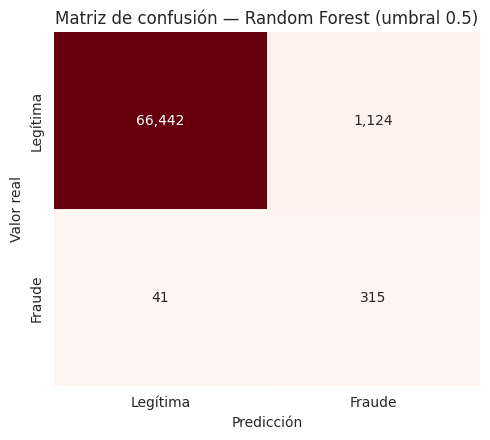

In [25]:
# confusion_matrix compara valores reales (y_test) contra predichos y arma la tabla 2x2
matriz = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(5, 4.5))
# heatmap dibuja la matriz como colores; fmt=',d' formatea los números como enteros con comas de miles
sns.heatmap(matriz, annot=True, fmt=',d', cmap='Reds', cbar=False,
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de confusión — Random Forest (umbral 0.5)')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

**Interpretación:** la esquina **inferior derecha** son los **verdaderos positivos** (fraudes detectados correctamente) y la esquina **inferior izquierda** son los **falsos negativos** (fraudes que el modelo dejó pasar — el error más costoso en este negocio). La esquina **superior derecha** son los **falsos positivos** (transacciones legítimas marcadas erróneamente como fraude, que generan fricción al cliente). Con el umbral estándar de 0.5, el modelo prioriza capturar fraude (pocos falsos negativos) a costa de más falsos positivos — algo que ajustamos en la sección 8.4.

### 8.2 Curva ROC

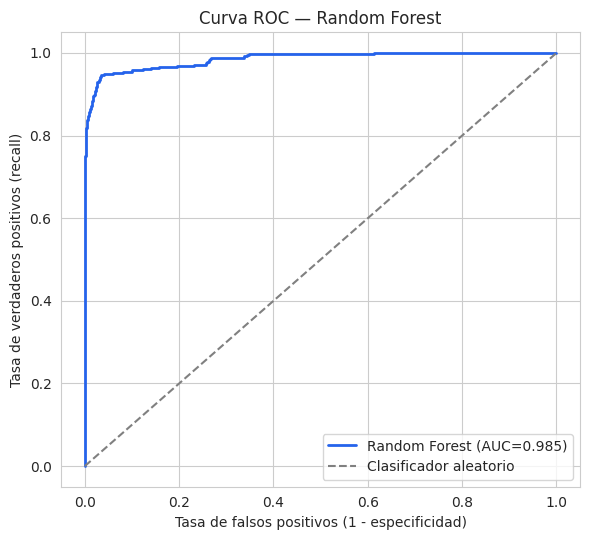

In [26]:
# roc_curve prueba TODOS los umbrales posibles y devuelve, para cada uno,
# la tasa de falsos positivos (fpr) y la tasa de verdaderos positivos (tpr)
fpr, tpr, _ = roc_curve(y_test, proba_rf)

plt.figure(figsize=(6, 5.5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_roc_rf:.3f})', color='#2563EB', linewidth=2)
# Línea diagonal de referencia: así se vería un modelo que predice al azar (AUC=0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos (1 - especificidad)')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curva ROC — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretación:** la curva ROC muestra el equilibrio entre detectar fraudes (eje Y) y generar falsas alarmas (eje X) en **todos** los umbrales posibles, no solo en 0.5. Cuanto más se acerca la curva a la esquina superior izquierda, mejor separa el modelo ambas clases. Random Forest (AUC=0.985) supera ampliamente al clasificador aleatorio (la diagonal punteada, AUC=0.5).

### 8.3 Curva Precision-Recall

En problemas tan desbalanceados como este, la curva **Precision-Recall es más informativa que la ROC**, porque no se ve "inflada" por la enorme cantidad de verdaderos negativos (transacciones legítimas correctamente identificadas), que en este dataset son la inmensa mayoría.

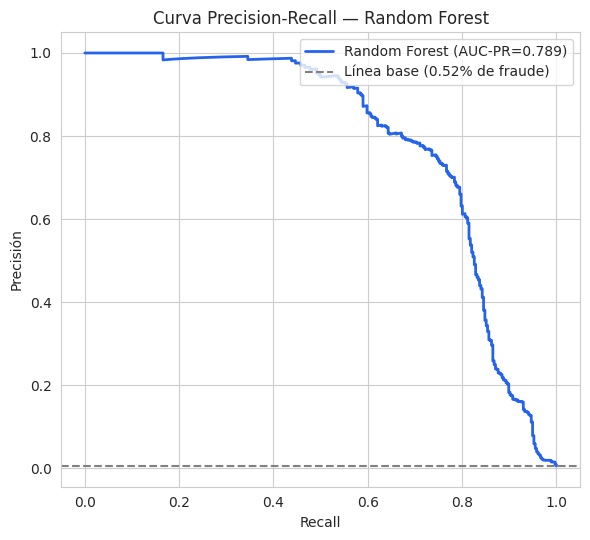

In [27]:
# precision_recall_curve prueba todos los umbrales posibles y devuelve, para cada uno,
# la precisión y el recall resultante
precision_arr, recall_arr, _ = precision_recall_curve(y_test, proba_rf)

plt.figure(figsize=(6, 5.5))
plt.plot(recall_arr, precision_arr, label=f'Random Forest (AUC-PR={auc_pr_rf:.3f})', color='#2563EB', linewidth=2)

# Línea base: la precisión que tendría un modelo que predice fraude completamente al azar
# (equivale a la proporción real de fraude en el set de prueba, ~0.52%)
tasa_base = y_test.mean()
plt.axhline(tasa_base, linestyle='--', color='gray', label=f'Línea base ({tasa_base*100:.2f}% de fraude)')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precision-Recall — Random Forest')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Interpretación:** la "línea base" gris (0.52%) representa el desempeño de un modelo que predice al azar — cualquier curva por encima de ella está agregando valor real. La brecha entre Random Forest y esa línea base es enorme (AUC-PR de 0.789 contra una línea base de 0.0052), confirmando que el modelo captura señal genuina y no ruido.

### 8.4 Optimización del umbral de decisión

Hasta ahora usamos el umbral por defecto (0.5), pero **no hay ninguna razón matemática para que 0.5 sea el mejor punto de corte** — es solo una convención. Buscamos el umbral que **maximiza el F1-score** (equilibrio entre precisión y recall) específicamente para Random Forest, nuestro modelo elegido.

In [28]:
# precision_recall_curve nos da, para cada umbral posible, la precisión y el recall resultante
precision_arr, recall_arr, umbrales_arr = precision_recall_curve(y_test, proba_rf)

# Calculamos el F1-score en cada punto (con un epsilon pequeño para evitar división entre cero)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-12)
indice_optimo = np.argmax(f1_arr[:-1])  # el último punto de la curva no tiene un umbral asociado
umbral_optimo = umbrales_arr[indice_optimo]

print(f'Umbral óptimo (máximo F1): {umbral_optimo:.3f}')
print(f'  -> Precisión: {precision_arr[indice_optimo]:.3f}  |  Recall: {recall_arr[indice_optimo]:.3f}  |  F1: {f1_arr[indice_optimo]:.3f}')
print()

# Comparamos varios umbrales posibles para ilustrar el trade-off
print('Comparación de umbrales:')
for umbral_prueba in [0.15, 0.30, 0.50, round(float(umbral_optimo), 2)]:
    pred_prueba = (proba_rf >= umbral_prueba).astype(int)
    print(f'  umbral={umbral_prueba:.2f}  ->  precisión={precision_score(y_test, pred_prueba):.3f}  '
          f'recall={recall_score(y_test, pred_prueba):.3f}  f1={f1_score(y_test, pred_prueba):.3f}')

Umbral óptimo (máximo F1): 0.705
  -> Precisión: 0.766  |  Recall: 0.736  |  F1: 0.751

Comparación de umbrales:
  umbral=0.15  ->  precisión=0.020  recall=0.972  f1=0.040
  umbral=0.30  ->  precisión=0.054  recall=0.955  f1=0.101
  umbral=0.50  ->  precisión=0.219  recall=0.885  f1=0.351
  umbral=0.70  ->  precisión=0.762  recall=0.736  f1=0.749


**Interpretación:** con el umbral óptimo (**≈0.70**), Random Forest pasa de una precisión de 21.9% (con umbral 0.5) a **76.2%**, con un recall de **73.6%** y un F1 de **0.749** — un salto enorme en calidad práctica. Esto **no cambia el modelo**, solo el punto en el que decidimos "a partir de qué probabilidad actuamos". En un sistema real conviene tener **dos umbrales**, no solo uno:

- Un umbral **bajo** (ej. 15%) para marcar transacciones como "revisar" (alerta temprana, red de seguridad amplia).
- Un umbral **alto** (≈70%, el óptimo que acabamos de calcular) para **bloquear automáticamente** sin intervención humana.

Esta es exactamente la lógica que implementamos en la calculadora interactiva (sección 10) y en la versión HTML/JavaScript.

## 9. Interpretabilidad del modelo

Un modelo de fraude no solo debe predecir bien: un analista humano necesita poder **explicar por qué** una transacción fue marcada como sospechosa (por regulación, por confianza del negocio, y para depurar errores). Usamos dos técnicas complementarias.

### 9.1 Importancia de variables (Feature Importance)

Random Forest calcula, para cada variable, cuánto contribuyó en promedio a reducir la "impureza" (el desorden entre clases) a lo largo de todos los árboles del bosque.

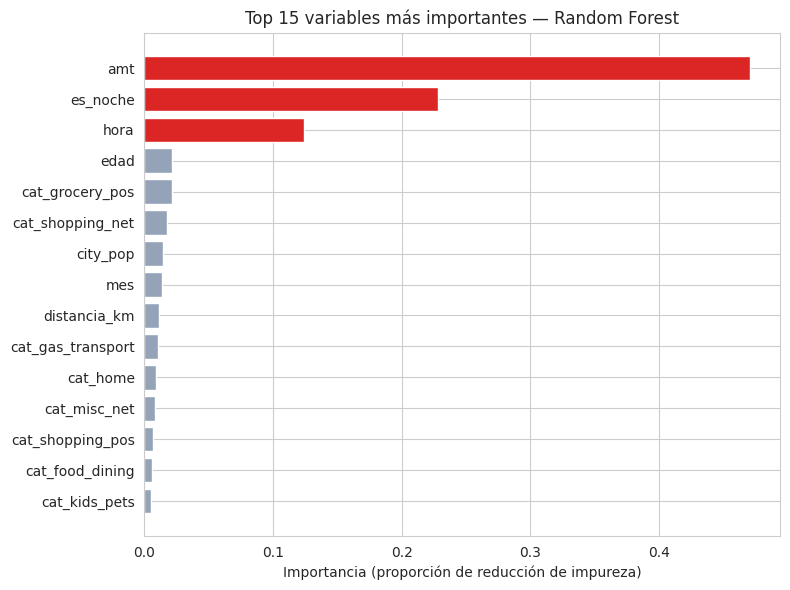

amt                  0.4706
es_noche             0.2281
hora                 0.1243
edad                 0.0216
cat_grocery_pos      0.0211
cat_shopping_net     0.0172
city_pop             0.0141
mes                  0.0137
distancia_km         0.0117
cat_gas_transport    0.0109
cat_home             0.0088
cat_misc_net         0.0084
cat_shopping_pos     0.0067
cat_food_dining      0.0057
cat_kids_pets        0.0048
dtype: float64


In [29]:
# feature_importances_ da un valor de importancia por variable (todos suman 1.0)
importancias = pd.Series(modelo_rf.feature_importances_, index=orden_final_features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top_15 = importancias.head(15)  # nos quedamos con las 15 variables más importantes (de 34 en total)
# Resaltamos en rojo las variables con más de 5% de importancia individual, para que destaquen las realmente decisivas
colores = [COLOR_FRAUDE if v > 0.05 else '#94A3B8' for v in top_15.values]
plt.barh(top_15.index[::-1], top_15.values[::-1], color=colores[::-1])  # [::-1] invierte el orden para que la más importante quede arriba
plt.xlabel('Importancia (proporción de reducción de impureza)')
plt.title('Top 15 variables más importantes — Random Forest')
plt.tight_layout()
plt.show()

print(top_15.round(4))

**Interpretación:** las tres variables más importantes son, por lejos, **`amt`** (47.1%), **`es_noche`** (22.8%) y **`hora`** (12.4%) — juntas explican más del **80%** del poder predictivo del modelo, confirmando cuantitativamente los patrones que ya habíamos observado visualmente en el EDA (secciones 3.4 y 3.5). Como anticipamos en 3.9, **`distancia_km` aparece con importancia baja** (~1.2%), validando que la distancia cliente-comercio no es un buen predictor de fraude *en este dataset en particular*, a pesar de la creencia común de que sí lo es.

### 9.2 Valores SHAP (SHapley Additive exPlanations)

Feature importance nos dice qué variables importan **en promedio**, pero no si empujan la predicción hacia "fraude" o hacia "legítima", ni cómo varía ese efecto según el valor de la variable. SHAP resuelve esto asignando, para **cada transacción individual**, cuánto contribuyó cada variable a alejar la predicción del promedio general.

Por eficiencia (SHAP es costoso computacionalmente), lo calculamos sobre una muestra aleatoria de 1,500 transacciones del conjunto de prueba en lugar de las 67,922 completas — es una práctica estándar y no cambia las conclusiones generales.

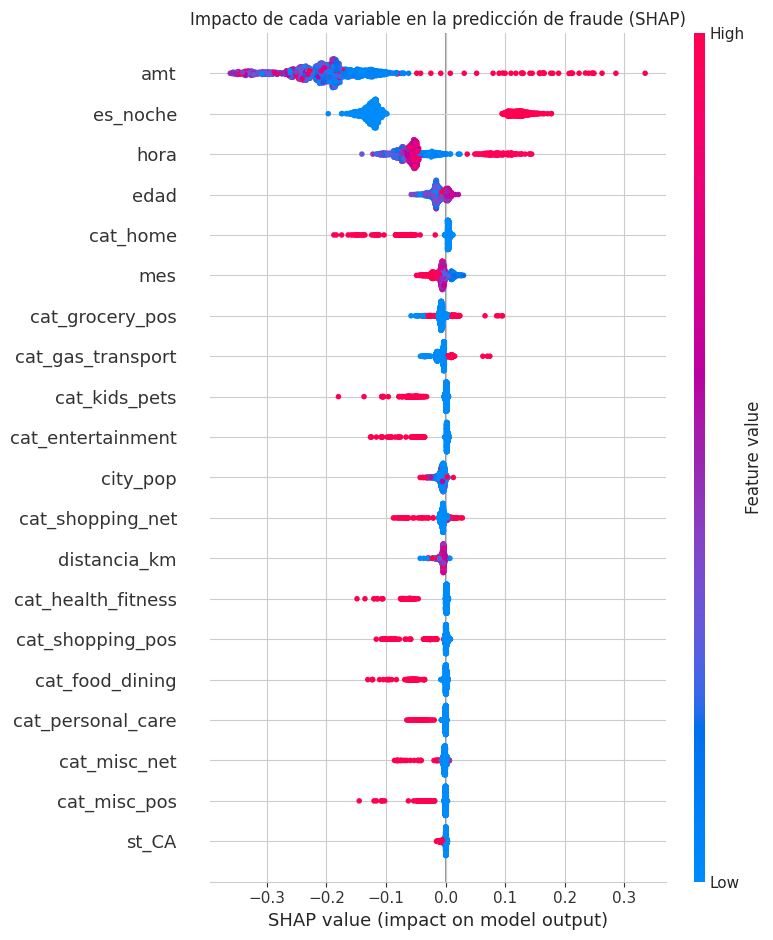

In [30]:
# TreeExplainer está optimizado específicamente para modelos basados en árboles como Random Forest
explicador_shap = shap.TreeExplainer(modelo_rf)

# Tomamos una muestra aleatoria para que el cálculo sea rápido
muestra_shap = X_test.sample(n=1500, random_state=RANDOM_STATE)

# Calculamos los valores SHAP para la muestra
valores_shap_crudos = explicador_shap.shap_values(muestra_shap)

# Según la versión de SHAP, el resultado puede venir como lista [clase_0, clase_1] o como array 3D (filas, variables, clases).
# Este bloque maneja ambos casos y siempre se queda con los valores correspondientes a la clase "fraude" (clase 1).
if isinstance(valores_shap_crudos, list):
    valores_shap_fraude = valores_shap_crudos[1]
elif valores_shap_crudos.ndim == 3:
    valores_shap_fraude = valores_shap_crudos[:, :, 1]
else:
    valores_shap_fraude = valores_shap_crudos

# Gráfico "beeswarm": cada punto es una transacción; el color indica si la variable tenía un valor alto (rojo) o bajo (azul)
shap.summary_plot(valores_shap_fraude, muestra_shap, show=False)
plt.title('Impacto de cada variable en la predicción de fraude (SHAP)')
plt.tight_layout()
plt.show()

**Interpretación:** en el gráfico, cada punto rojo a la derecha (valor SHAP positivo) representa una transacción donde un valor **alto** de esa variable empujó la predicción hacia "fraude". Confirmamos que valores **altos de `amt`** (rojo, a la derecha) empujan fuertemente hacia fraude, y lo mismo ocurre cuando **`es_noche`=1**. El patrón inverso (puntos azules a la izquierda) muestra que montos bajos y horario diurno empujan la predicción hacia "legítima". Esta vista complementa a la importancia de variables: no solo nos dice *qué* importa, sino *en qué dirección* y *con qué consistencia*.

### 9.3 Explicación de un caso individual

Para ilustrar cómo SHAP explica una predicción concreta, elegimos una transacción del conjunto de prueba que **sí fue fraude real** y mostramos qué variables influyeron en la predicción del modelo para ese caso puntual.

Transacción de ejemplo (fraude real):
amt             22.52
hora            22.00
es_noche         1.00
edad            43.00
city_pop    190249.00
Name: 166173, dtype: float64

Probabilidad predicha por el modelo: 59.7%


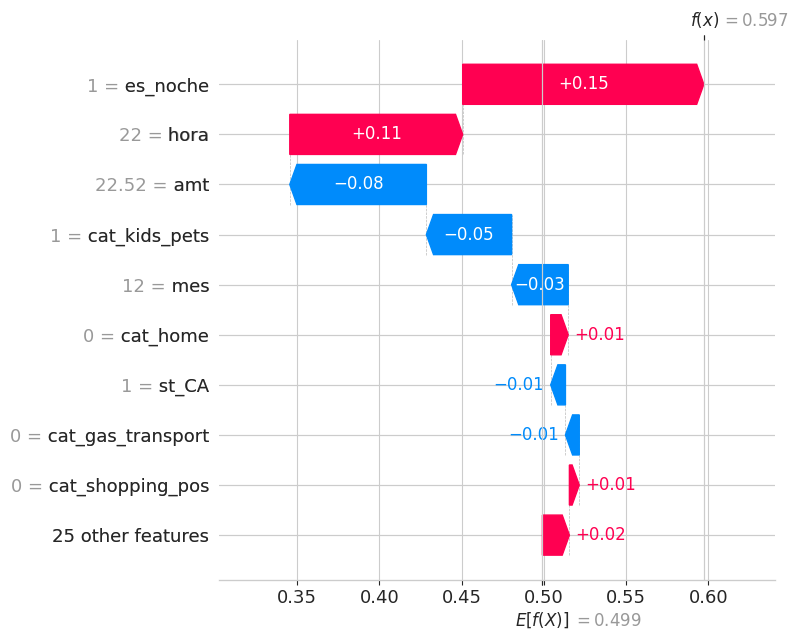

In [31]:
# Buscamos el índice, dentro de nuestra muestra, de una transacción que realmente fue fraude
indices_fraude_en_muestra = np.where(y_test.loc[muestra_shap.index].values == 1)[0]

if len(indices_fraude_en_muestra) > 0:
    idx_ejemplo = indices_fraude_en_muestra[0]
    fila_ejemplo = muestra_shap.iloc[idx_ejemplo]

    print('Transacción de ejemplo (fraude real):')
    print(fila_ejemplo[['amt', 'hora', 'es_noche', 'edad', 'city_pop']])
    print(f'\nProbabilidad predicha por el modelo: {modelo_rf.predict_proba([fila_ejemplo])[0,1]*100:.1f}%')

    # Gráfico de cascada (waterfall): muestra cómo cada variable "empuja" la predicción
    # desde el valor base (promedio general) hasta la predicción final para ESTE caso puntual
    explicacion_individual = shap.Explanation(
        values=valores_shap_fraude[idx_ejemplo],
        base_values=explicador_shap.expected_value[1] if isinstance(explicador_shap.expected_value, (list, np.ndarray)) else explicador_shap.expected_value,
        data=fila_ejemplo.values,
        feature_names=list(muestra_shap.columns)
    )
    shap.plots.waterfall(explicacion_individual, max_display=10, show=False)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró ningún fraude en esta muestra aleatoria; ejecuta de nuevo con otra semilla si quieres ver este ejemplo.')

**Interpretación:** el gráfico de cascada muestra, para esta transacción específica, cómo cada variable fue sumando (rojo) o restando (azul) probabilidad de fraude, partiendo del promedio general del modelo (`base_values`) hasta llegar a la predicción final. Este tipo de explicación es exactamente lo que un analista de fraude necesitaría ver al revisar manualmente un caso marcado por el sistema: no solo "el modelo dice 87% de probabilidad de fraude", sino **por qué**.

## 10. Simulador interactivo de predicción

Construimos una función que recibe los datos de una transacción en lenguaje natural (monto, hora, categoría, etc.), arma el vector de variables en el orden correcto y devuelve la probabilidad de fraude según Random Forest — la misma lógica, exactamente, que replicaremos en JavaScript en la sección 11.

In [32]:
# Valores por defecto (mediana/típicos) para las variables que no se piden explícitamente en la demo
EDAD_POR_DEFECTO = 46
POBLACION_POR_DEFECTO = 1645
DISTANCIA_POR_DEFECTO = 75.6

def construir_vector_transaccion(monto, hora_dia, categoria, estado='CA', mes_transaccion=6,
                                   edad=EDAD_POR_DEFECTO, poblacion_ciudad=POBLACION_POR_DEFECTO,
                                   distancia=DISTANCIA_POR_DEFECTO):
    # Empezamos con todas las variables en 0 (para que las dummy de categoría/estado no
    # seleccionadas queden correctamente en 0)
    fila = {columna: 0.0 for columna in orden_final_features}

    # Rellenamos las variables numéricas con los valores recibidos
    fila['amt'] = float(monto)
    fila['hora'] = float(hora_dia)
    fila['es_noche'] = 1.0 if hora_dia in [22, 23, 0, 1, 2, 3] else 0.0  # se calcula automáticamente, no se pide al usuario
    fila['mes'] = float(mes_transaccion)
    fila['edad'] = float(edad)
    fila['city_pop'] = float(poblacion_ciudad)
    fila['distancia_km'] = float(distancia)

    # Activamos (=1) únicamente la columna dummy de la categoría y el estado elegidos
    columna_categoria = f'cat_{categoria}'
    if columna_categoria in fila:
        fila[columna_categoria] = 1.0

    columna_estado = f'st_{estado}'
    if columna_estado in fila:
        fila[columna_estado] = 1.0

    # Devolvemos un DataFrame de una sola fila, en el mismo orden de columnas que usó el entrenamiento
    return pd.DataFrame([fila])[orden_final_features]


def predecir_probabilidad_fraude(monto, hora_dia, categoria, **kwargs):
    vector_entrada = construir_vector_transaccion(monto, hora_dia, categoria, **kwargs)
    probabilidad = modelo_rf.predict_proba(vector_entrada)[0, 1]
    return probabilidad


# --- Ejemplo 1: transacción típica y de bajo riesgo ---
p1 = predecir_probabilidad_fraude(monto=45, hora_dia=14, categoria='home')
print(f'Ejemplo 1 (compra de \$45 en "home" a las 14h):        {p1*100:.2f}% de probabilidad de fraude')

# --- Ejemplo 2: transacción de riesgo moderado (similar a la imagen de referencia) ---
p2 = predecir_probabilidad_fraude(monto=310, hora_dia=23, categoria='shopping_net')
print(f'Ejemplo 2 (compra de \$310 en "shopping_net" a las 23h): {p2*100:.2f}% de probabilidad de fraude')

# --- Ejemplo 3: transacción de alto riesgo ---
p3 = predecir_probabilidad_fraude(monto=1200, hora_dia=2, categoria='misc_net')
print(f'Ejemplo 3 (compra de \$1200 en "misc_net" a las 02h):   {p3*100:.2f}% de probabilidad de fraude')

Ejemplo 1 (compra de \$45 en "home" a las 14h):        1.74% de probabilidad de fraude
Ejemplo 2 (compra de \$310 en "shopping_net" a las 23h): 57.78% de probabilidad de fraude
Ejemplo 3 (compra de \$1200 en "misc_net" a las 02h):   74.57% de probabilidad de fraude


**Interpretación:** el patrón responde exactamente a lo aprendido en el EDA: una compra pequeña, de día, en una categoría segura, obtiene una probabilidad mínima; a medida que sube el monto, se acerca a la madrugada y cambia a una categoría de riesgo, la probabilidad estimada de fraude aumenta con fuerza. Este comportamiento gradual y coherente es una buena señal de que el modelo generalizó patrones reales y no ruido.

### 10.1 Calculadora interactiva con controles deslizantes

La siguiente celda crea controles interactivos (`ipywidgets`) directamente en el notebook: al mover los sliders o cambiar la categoría, la probabilidad se recalcula en tiempo real. Es el equivalente, dentro de Colab, de la calculadora que verás en la versión HTML/JavaScript.

In [33]:
import ipywidgets as widgets                       # librería de controles interactivos (sliders, dropdowns) para notebooks
from IPython.display import display, clear_output  # display muestra los widgets; clear_output limpia el resultado anterior

# Listas de opciones reales para los controles (idénticas a las de la fase de modelado)
lista_categorias = sorted(df['category'].unique().tolist())

# --- Definimos los controles interactivos ---
slider_monto = widgets.FloatSlider(
    value=310, min=1, max=1500, step=1,             # valor inicial, mínimo, máximo y paso del slider
    description='Monto (USD):',
    style={'description_width': '100px'}, layout=widgets.Layout(width='420px')
)
slider_hora = widgets.IntSlider(
    value=23, min=0, max=23, step=1,                 # rango 0-23 (una hora del día)
    description='Hora (0-23):',
    style={'description_width': '100px'}, layout=widgets.Layout(width='420px')
)
selector_categoria = widgets.Dropdown(
    options=lista_categorias, value='shopping_net',  # lista desplegable con las 14 categorías reales del dataset
    description='Categoría:', style={'description_width': '100px'}
)
salida = widgets.Output()  # área donde se imprime el resultado del cálculo (se redibuja en cada cambio)

def actualizar_calculo(cambio=None):
    # cambio=None permite llamar a esta función manualmente (sin un evento real) para el cálculo inicial
    with salida:
        clear_output(wait=True)  # borra el resultado anterior antes de imprimir el nuevo (evita que se acumulen impresiones)

        # Reutilizamos la misma función de predicción de la celda anterior
        probabilidad = predecir_probabilidad_fraude(slider_monto.value, slider_hora.value, selector_categoria.value)
        es_noche_actual = slider_hora.value in [22, 23, 0, 1, 2, 3]

        # Clasificamos el riesgo usando los mismos dos umbrales definidos en la sección 8.4
        if probabilidad >= 0.70:
            etiqueta = 'ALTO RIESGO - BLOQUEAR'
        elif probabilidad >= 0.15:
            etiqueta = 'RIESGO MODERADO - REVISAR'
        else:
            etiqueta = 'RIESGO BAJO - APROBAR'

        print(f'Probabilidad estimada de fraude: {probabilidad*100:.1f}%')
        print(f'Horario nocturno (22h-03h): {"Sí" if es_noche_actual else "No"}')
        print(f'Clasificación: {etiqueta}')

# .observe() conecta cada control con la función: cualquier cambio de valor dispara un recálculo automático
slider_monto.observe(actualizar_calculo, names='value')
slider_hora.observe(actualizar_calculo, names='value')
selector_categoria.observe(actualizar_calculo, names='value')

display(slider_monto, slider_hora, selector_categoria, salida)  # renderiza los controles y el área de resultado
actualizar_calculo()  # ejecutamos el cálculo una primera vez para mostrar un resultado inicial al cargar la celda

FloatSlider(value=310.0, description='Monto (USD):', layout=Layout(width='420px'), max=1500.0, min=1.0, step=1…

IntSlider(value=23, description='Hora (0-23):', layout=Layout(width='420px'), max=23, style=SliderStyle(descri…

Dropdown(description='Categoría:', index=11, options=('entertainment', 'food_dining', 'gas_transport', 'grocer…

Output()

**Interpretación:** esta celda es completamente interactiva **cuando la ejecutas tú mismo en Colab** (mover los sliders recalcula la probabilidad al instante). Si solo estás leyendo el notebook ya ejecutado, verás el resultado congelado en los valores iniciales (monto=\$310, hora=23h, categoría=`shopping_net`).

## 11. Exportación del modelo

Guardamos el modelo de dos formas distintas, para dos usos distintos:

1. **`joblib`**: el formato nativo de scikit-learn, para volver a cargar el modelo en Python (por ejemplo, en una API con Flask/FastAPI) sin tener que reentrenar.
2. **`JSON`**: una representación liviana de la estructura interna de cada árbol del bosque (qué variable pregunta, con qué umbral, y hacia qué nodo va en cada rama), pensada para que un motor de JavaScript pueda **recorrer los árboles y calcular la misma probabilidad, directamente en el navegador**, sin necesidad de un servidor. Esta es la pieza que conecta este notebook con la versión HTML/JavaScript entregada junto a este archivo.

In [34]:
# --- 1. Guardado en formato joblib (para reutilizar el modelo en Python) ---
joblib.dump(modelo_rf, 'modelo_random_forest.joblib')
print('Modelo guardado como modelo_random_forest.joblib')


# --- 2. Exportación a JSON (para la demo en JavaScript) ---

def arbol_a_estructura_json(arbol_individual):
    # Cada árbol de sklearn guarda su estructura interna en el atributo .tree_
    t = arbol_individual.tree_
    nodos = []
    for i in range(t.node_count):
        # Si el hijo izquierdo y derecho son el mismo nodo, significa que es una HOJA (nodo final)
        if t.children_left[i] == t.children_right[i]:
            distribucion_clases = t.value[i][0]                       # [n_legitimas, n_fraudes] en esa hoja
            total = distribucion_clases.sum()
            probabilidad_fraude_hoja = float(distribucion_clases[1] / total) if total > 0 else 0.0
            # Formato de hoja: [1, probabilidad]
            nodos.append([1, probabilidad_fraude_hoja])
        else:
            # Formato de nodo de decisión: [0, indice_variable, umbral, nodo_izquierdo, nodo_derecho]
            nodos.append([
                0,
                int(t.feature[i]),
                float(t.threshold[i]),
                int(t.children_left[i]),
                int(t.children_right[i]),
            ])
    return nodos


# Construimos el diccionario completo que exportaremos
modelo_exportado = {
    'feature_names': orden_final_features,                                  # orden EXACTO de las variables
    'trees': [arbol_a_estructura_json(arbol) for arbol in modelo_rf.estimators_],  # los 150 árboles del bosque
    'metadata': {
        'n_estimators': len(modelo_rf.estimators_),
        'umbral_revision': 0.15,
        'umbral_bloqueo': round(float(umbral_optimo), 3),
        'metricas_test': {
            'auc_roc': round(float(auc_roc_rf), 4),
            'auc_pr': round(float(auc_pr_rf), 4),
        },
        'valores_por_defecto': {
            'edad': EDAD_POR_DEFECTO,
            'city_pop': POBLACION_POR_DEFECTO,
            'distancia_km': DISTANCIA_POR_DEFECTO,
            'mes': 6,
            'estado': 'CA',
        }
    }
}

with open('modelo_random_forest.json', 'w') as archivo_json:
    json.dump(modelo_exportado, archivo_json, separators=(',', ':'))  # separators sin espacios = archivo más liviano

tamano_kb = os.path.getsize('modelo_random_forest.json') / 1024
print(f'Modelo exportado como modelo_random_forest.json ({tamano_kb:.1f} KB, {len(modelo_rf.estimators_)} árboles)')

# En Google Colab, estas líneas descargan los archivos directamente a tu computadora.
# Si no estás en Colab (Jupyter local), los archivos ya quedaron guardados en la carpeta del notebook.
try:
    from google.colab import files
    files.download('modelo_random_forest.joblib')
    files.download('modelo_random_forest.json')
except ImportError:
    print('Archivos guardados localmente (no se detectó entorno de Google Colab).')

Modelo guardado como modelo_random_forest.joblib
Modelo exportado como modelo_random_forest.json (933.2 KB, 150 árboles)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Interpretación:** el archivo `modelo_random_forest.json` pesa menos de 1 MB a pesar de contener **150 árboles completos** — es perfectamente viable incrustarlo dentro de una página web y hacer que el navegador del usuario calcule la predicción localmente, sin enviar los datos de la transacción a ningún servidor externo (una ventaja adicional de privacidad). La versión HTML/JavaScript entregada junto a este notebook recorre esta misma estructura de árboles con una función equivalente a `construir_vector_transaccion` + un recorrido de árbol, y produce **exactamente la misma probabilidad** que este notebook en Python.

## 12. Conclusiones y recomendaciones

### Resumen de resultados

| Métrica | Valor |
|---|---|
| AUC-ROC | 0.985 |
| AUC-PR | 0.789 |
| Precisión (umbral 0.5) | 21.9% |
| Recall (umbral 0.5) | 88.5% |
| Precisión (umbral óptimo 0.70) | 76.2% |
| Recall (umbral óptimo 0.70) | 73.6% |

### Hallazgos clave del negocio

- **El monto de la transacción, el horario nocturno (22:00-03:00) y la hora del día** concentran más del 80% del poder predictivo del modelo. Un sistema de reglas simple que vigile "montos altos de madrugada" ya captaría buena parte del riesgo, aunque con muchas más falsas alarmas que el modelo de Machine Learning.
- **`shopping_net`, `grocery_pos` y `misc_net`** son las categorías de mayor riesgo — vale la pena aplicar fricción adicional (verificación en dos pasos, límites de monto más bajos) específicamente en comercios de estas categorías durante horario nocturno.
- **La distancia entre el cliente y el comercio, contrario a la creencia común, no diferencia el fraude en este dataset.** Es un recordatorio de que los supuestos deben validarse con datos reales antes de construir reglas de negocio sobre ellos.
- **Un único umbral de decisión no es suficiente.** Recomendamos operar con dos: uno bajo (~15%) para marcar transacciones a revisar manualmente, y uno alto (~70%, calculado como óptimo de F1) para bloqueo automático inmediato.
- **Un modelo de regresión (lineal o logística) no era la herramienta adecuada para este problema** (ver sección 7.1): la señal de fraude vive en interacciones entre variables, no en efectos aditivos individuales, y Random Forest captura esas interacciones sin necesitar ingeniería manual de términos de interacción.

### Limitaciones

- El dataset es sintético (generado con el simulador Sparkov) y geográficamente limitado al oeste de Estados Unidos; los patrones de fraude en datos reales de Perú u otro mercado podrían diferir en variables como categoría de comercio o rango horario.
- Con solo 1,782 casos de fraude en total, el modelo tiene relativamente pocos ejemplos positivos de los que aprender; más datos de fraude (o técnicas como SMOTE) podrían mejorar aún más la precisión.
- El modelo no incorpora variables de comportamiento histórico del cliente (por ejemplo, "gasto promedio de este cliente en los últimos 30 días"), que en sistemas de producción reales suelen ser algunas de las señales más fuertes.
- Al usar un único modelo (Random Forest) en vez de comparar contra alternativas como XGBoost, se prioriza la simplicidad de mantenimiento y despliegue sobre exprimir el último punto porcentual de desempeño.

### Próximos pasos sugeridos

1. Incorporar variables de comportamiento histórico por cliente/tarjeta (velocidad de transacciones, desviación respecto al gasto habitual).
2. Reentrenar periódicamente el modelo a medida que cambian los patrones de fraude (*concept drift*).
3. Si en el futuro se prioriza exprimir el máximo desempeño posible por encima de la simplicidad, evaluar modelos de gradient boosting (por ejemplo, XGBoost o LightGBM) como alternativa a Random Forest.
4. Monitorear en producción la tasa de falsos positivos por categoría de comercio, ya que el costo de fricción al cliente no es el mismo en todas ellas.